Please refactor the model to follow Monk's method directly. Produce a clean python module suitable for pasting into a notebook. Retain all the key features such as helper functions.

Arrivals:
  stroke        :   895
  tia           :   122
  complex_neuro :   305
  other         :   346

Mean daily occupancies:
  acute   :    5.110
  rehab   :    4.996
  esd     :    2.193

Current-capacity p(delay) estimates:
  acute @ 10 beds: 0.0730  1 in every 13.7 patients delayed
  rehab @ 12 beds: 0.0109  1 in every 91.3 patients delayed


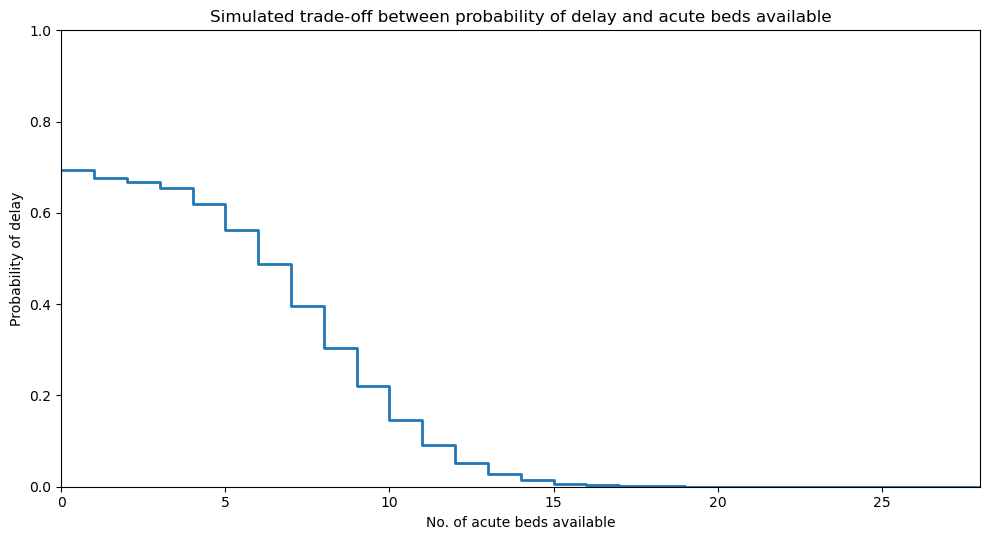

In [1]:
"""
stroke_pathway_monks.py

Refactored stroke pathway simulation following the method described by Monks et al.

Key methodological features
---------------------------
- Unconstrained simulation of patient flow ("unfettered demand")
- No bed/service capacity limits within the simulation itself
- Daily audit of occupancy for each service
- Probability of delay derived post hoc from occupancy exceedance:
      p(delay | capacity = B) = P(occupancy > B)

Python: 3.11
SimPy:  4.1.1

Pathway modelled
----------------
External arrivals -> Acute -> {Rehab, ESD, Other}
Optional direct transfers from elsewhere -> Rehab -> {ESD, Other}

Occupancy is tracked for:
- acute
- rehab
- esd

Notes
-----
1. This follows Monks' "unfettered demand" approach, so there are no queues and
   no capacity-constrained resources in the simulation.

2. Lengths of stay:
   - Acute and rehab LOS are lognormal using supplied arithmetic mean and SD.
   - ESD LOS was not supplied in the prompt, so a configurable placeholder
     exponential distribution is used by default. Replace with paper values
     if available.

3. Stroke ESD eligibility:
   The paper reports:
       ESD total n = 463
       from acute n = 300
       from rehab n = 163
   The supplied transfer matrices are retained for non-stroke categories.
   For stroke, the acute->ESD and rehab->ESD probabilities in the scenario
   are still used as defaults.

4. p(delay) is estimated from daily occupancy audit:
       p(delay at B beds) = proportion of audit days with occupancy > B
"""

from __future__ import annotations

from dataclasses import dataclass, field
from typing import Optional, Sequence, Iterable
import math

import matplotlib.pyplot as plt
import numpy as np
import simpy


# ============================================================
# Trace utility
# ============================================================

TRACE = False


def trace(msg: str) -> None:
    """Conditionally print trace output."""
    if TRACE:
        print(msg)


# ============================================================
# Distribution classes
# ============================================================

class Distribution:
    """Base class for seedable distributions."""

    def __init__(self, random_seed: Optional[int] = None) -> None:
        self.rng = np.random.default_rng(random_seed)


class Exponential(Distribution):
    """Exponential distribution parameterised by arithmetic mean."""

    def __init__(self, mean: float, random_seed: Optional[int] = None) -> None:
        if mean <= 0:
            raise ValueError("Exponential mean must be > 0.")
        super().__init__(random_seed=random_seed)
        self.mean = float(mean)

    def sample(self) -> float:
        return float(self.rng.exponential(scale=self.mean))


class Lognormal(Distribution):
    """Lognormal distribution parameterised by mu and sigma of the underlying normal."""

    def __init__(self, mu: float, sigma: float, random_seed: Optional[int] = None) -> None:
        if sigma <= 0:
            raise ValueError("Lognormal sigma must be > 0.")
        super().__init__(random_seed=random_seed)
        self.mu = float(mu)
        self.sigma = float(sigma)

    def sample(self) -> float:
        return float(self.rng.lognormal(mean=self.mu, sigma=self.sigma))

    @classmethod
    def from_mean_sd(
        cls,
        mean: float,
        sd: float,
        random_seed: Optional[int] = None,
    ) -> "Lognormal":
        """
        Construct a lognormal distribution from arithmetic mean and SD.

        For X ~ Lognormal(mu, sigma):
            sigma^2 = ln(1 + sd^2 / mean^2)
            mu      = ln(mean) - sigma^2 / 2
        """
        if mean <= 0:
            raise ValueError("Lognormal mean must be > 0.")
        if sd <= 0:
            raise ValueError("Lognormal sd must be > 0.")

        variance = sd ** 2
        sigma_sq = math.log(1.0 + variance / (mean ** 2))
        sigma = math.sqrt(sigma_sq)
        mu = math.log(mean) - 0.5 * sigma_sq
        return cls(mu=mu, sigma=sigma, random_seed=random_seed)


# ============================================================
# Data model
# ============================================================

@dataclass
class Patient:
    """Represents one patient flowing through the pathway."""
    id: int
    category: str
    arrival_time: float
    source: str = "external"

    acute_start_time: Optional[float] = None
    acute_end_time: Optional[float] = None

    rehab_start_time: Optional[float] = None
    rehab_end_time: Optional[float] = None

    esd_start_time: Optional[float] = None
    esd_end_time: Optional[float] = None

    final_destination: Optional[str] = None


class IdCounter:
    """Simple incrementing patient ID generator."""

    def __init__(self, start: int = 1) -> None:
        self._next = start

    def next_id(self) -> int:
        value = self._next
        self._next += 1
        return value


# ============================================================
# Scenario container
# ============================================================

@dataclass
class Scenario:
    """
    Container for model parameters.

    Defaults represent the base-case scenario.
    """

    random_seed: int = 42

    categories: tuple[str, ...] = ("stroke", "tia", "complex_neuro", "other")

    # Base-period counts (reference only)
    base_period_counts: dict[str, int] = field(default_factory=lambda: {
        "stroke": 1320,
        "tia": 158,
        "complex_neuro": 456,
        "other": 510,
    })

    # Base mean inter-arrival times (days)
    mean_iat_days: dict[str, float] = field(default_factory=lambda: {
        "stroke": 1.2,
        "tia": 9.3,
        "complex_neuro": 3.6,
        "other": 3.2,
    })

    # Demand multipliers applied to ARRIVAL RATES
    # effective mean IAT = base mean IAT / demand_multiplier
    demand_multipliers: dict[str, float] = field(default_factory=lambda: {
        "stroke": 1.0,
        "tia": 1.0,
        "complex_neuro": 1.0,
        "other": 1.0,
    })

    # To exclude a group, multiply mean IAT by a large number
    exclusion_multipliers: dict[str, float] = field(default_factory=lambda: {
        "stroke": 1.0,
        "tia": 1.0,
        "complex_neuro": 1.0,
        "other": 1.0,
    })

    # Nominal current capacities from the paper
    acute_capacity: int = 10
    rehab_capacity: int = 12

    # ESD "capacity" is used only for post hoc p(delay) calculations, not simulation constraints
    esd_capacity: int = 999999

    # Optional direct transfers from elsewhere into rehab
    enable_transfer_from_elsewhere: bool = False
    transfer_from_elsewhere_mean_iat_days: Optional[float] = None
    transfer_from_elsewhere_category_probs: dict[str, float] = field(default_factory=lambda: {
        "stroke": 0.0,
        "tia": 0.0,
        "complex_neuro": 0.0,
        "other": 0.0,
    })

    # Acute LOS parameters (mean, sd), all lognormal
    acute_los_mean_sd: dict[str, tuple[float, float]] = field(default_factory=lambda: {
        "stroke_no_esd": (7.4, 8.6),
        "stroke_esd": (4.6, 4.8),
        "stroke_mortality": (7.0, 8.7),  # currently unused
        "tia": (1.8, 2.3),
        "complex_neuro": (4.0, 5.0),
        "other": (3.8, 5.2),
    })

    # Rehab LOS parameters (mean, sd), all lognormal
    rehab_los_mean_sd: dict[str, tuple[float, float]] = field(default_factory=lambda: {
        "stroke_no_esd": (28.4, 27.2),
        "stroke_esd": (30.3, 23.1),
        "complex_neuro": (27.6, 28.4),
        "other": (16.1, 14.1),
        "tia": (18.7, 23.5),
    })

    # ESD LOS placeholder (replace if paper gives a better value)
    esd_mean_los_days: float = 14.0

    # Acute -> destination probabilities
    acute_transfer_probs: dict[str, dict[str, float]] = field(default_factory=lambda: {
        "stroke": {"rehab": 0.24, "esd": 0.13, "other": 0.63},
        "tia": {"rehab": 0.01, "esd": 0.01, "other": 0.98},
        "complex_neuro": {"rehab": 0.11, "esd": 0.05, "other": 0.84},
        "other": {"rehab": 0.05, "esd": 0.10, "other": 0.85},
    })

    # Rehab -> destination probabilities
    rehab_transfer_probs: dict[str, dict[str, float]] = field(default_factory=lambda: {
        "stroke": {"esd": 0.40, "other": 0.60},
        "tia": {"esd": 0.00, "other": 1.00},
        "complex_neuro": {"esd": 0.09, "other": 0.91},
        "other": {"esd": 0.13, "other": 0.88},  # normalised in __post_init__
    })

    def __post_init__(self) -> None:
        category_set = set(self.categories)

        for mapping_name, mapping in [
            ("base_period_counts", self.base_period_counts),
            ("mean_iat_days", self.mean_iat_days),
            ("demand_multipliers", self.demand_multipliers),
            ("exclusion_multipliers", self.exclusion_multipliers),
            ("acute_transfer_probs", self.acute_transfer_probs),
            ("rehab_transfer_probs", self.rehab_transfer_probs),
            ("transfer_from_elsewhere_category_probs", self.transfer_from_elsewhere_category_probs),
        ]:
            missing = category_set - set(mapping)
            extra = set(mapping) - category_set
            if missing or extra:
                raise ValueError(
                    f"{mapping_name} keys mismatch. missing={missing}, extra={extra}"
                )

        if self.acute_capacity <= 0:
            raise ValueError("acute_capacity must be > 0.")
        if self.rehab_capacity <= 0:
            raise ValueError("rehab_capacity must be > 0.")
        if self.esd_capacity <= 0:
            raise ValueError("esd_capacity must be > 0.")
        if self.esd_mean_los_days <= 0:
            raise ValueError("esd_mean_los_days must be > 0.")

        for cat in self.categories:
            if self.mean_iat_days[cat] <= 0:
                raise ValueError(f"mean_iat_days[{cat}] must be > 0.")
            if self.demand_multipliers[cat] <= 0:
                raise ValueError(f"demand_multipliers[{cat}] must be > 0.")
            if self.exclusion_multipliers[cat] <= 0:
                raise ValueError(f"exclusion_multipliers[{cat}] must be > 0.")

        # Normalise rounding discrepancies in transfer matrices
        for name, matrix in [
            ("acute_transfer_probs", self.acute_transfer_probs),
            ("rehab_transfer_probs", self.rehab_transfer_probs),
        ]:
            for cat, probs in matrix.items():
                total = sum(probs.values())
                if total <= 0:
                    raise ValueError(f"{name}[{cat}] probabilities must sum to > 0.")
                if abs(total - 1.0) > 1e-12:
                    for key in probs:
                        probs[key] = probs[key] / total

        if self.enable_transfer_from_elsewhere:
            if (
                self.transfer_from_elsewhere_mean_iat_days is None
                or self.transfer_from_elsewhere_mean_iat_days <= 0
            ):
                raise ValueError(
                    "transfer_from_elsewhere_mean_iat_days must be provided and > 0 "
                    "when enable_transfer_from_elsewhere=True."
                )
            total = sum(self.transfer_from_elsewhere_category_probs.values())
            if total <= 0:
                raise ValueError(
                    "transfer_from_elsewhere_category_probs must sum to > 0 "
                    "when enable_transfer_from_elsewhere=True."
                )
            for key in self.transfer_from_elsewhere_category_probs:
                self.transfer_from_elsewhere_category_probs[key] /= total

    def effective_mean_iat(self, category: str) -> float:
        """
        Effective mean inter-arrival time after applying:
        - demand multiplier to arrival rate
        - exclusion multiplier to mean IAT
        """
        base = self.mean_iat_days[category]
        demand_factor = self.demand_multipliers[category]
        exclusion_factor = self.exclusion_multipliers[category]
        return (base / demand_factor) * exclusion_factor


# ============================================================
# Utility functions
# ============================================================

def sample_from_probs(rng: np.random.Generator, probs: dict[str, float]) -> str:
    """Sample one key from a probability dictionary."""
    labels = list(probs.keys())
    p = np.array(list(probs.values()), dtype=float)
    p = p / p.sum()
    return str(rng.choice(labels, p=p))


def safe_div(numerator: float, denominator: float) -> float:
    """Safe division returning 0.0 if denominator is zero."""
    return float(numerator / denominator) if denominator > 0 else 0.0


def reciprocal_delay_text(p_delay: float) -> str:
    """Format p(delay) as a clinician-friendly reciprocal."""
    if p_delay <= 0:
        return "No delays observed"
    return f"1 in every {1.0 / p_delay:.1f} patients delayed"


def exceedance_probability(values: Sequence[float], threshold: float) -> float:
    """Proportion of values strictly greater than threshold."""
    if len(values) == 0:
        return 0.0
    arr = np.asarray(values, dtype=float)
    return float(np.mean(arr > threshold))


# ============================================================
# Main model
# ============================================================

class StrokePathwayMonksModel:
    """
    Unconstrained pathway model with daily occupancy audit.

    Occupancy is tracked as the number of patients currently in:
    - acute
    - rehab
    - esd
    """

    def __init__(self, scenario: Scenario) -> None:
        self.scenario = scenario
        self.env = simpy.Environment()

        self.master_rng = np.random.default_rng(scenario.random_seed)

        # Arrival processes
        self.arrival_dists: dict[str, Exponential] = {
            cat: Exponential(
                mean=scenario.effective_mean_iat(cat),
                random_seed=self._next_seed(),
            )
            for cat in scenario.categories
        }

        self.transfer_from_elsewhere_dist: Optional[Exponential] = None
        if scenario.enable_transfer_from_elsewhere:
            self.transfer_from_elsewhere_dist = Exponential(
                mean=scenario.transfer_from_elsewhere_mean_iat_days,  # type: ignore[arg-type]
                random_seed=self._next_seed(),
            )

        # LOS distributions
        self.acute_los_dists: dict[str, Lognormal] = {
            key: Lognormal.from_mean_sd(mean=m, sd=s, random_seed=self._next_seed())
            for key, (m, s) in scenario.acute_los_mean_sd.items()
        }
        self.rehab_los_dists: dict[str, Lognormal] = {
            key: Lognormal.from_mean_sd(mean=m, sd=s, random_seed=self._next_seed())
            for key, (m, s) in scenario.rehab_los_mean_sd.items()
        }
        self.esd_los_dist = Exponential(
            mean=scenario.esd_mean_los_days,
            random_seed=self._next_seed(),
        )

        # Routing RNG
        self.routing_rng = np.random.default_rng(self._next_seed())

        # Patient tracking
        self.id_counter = IdCounter(start=1)
        self.patients: list[Patient] = []

        # Instantaneous occupancy counters
        self.n_acute = 0
        self.n_rehab = 0
        self.n_esd = 0

        # Daily occupancy audit
        self.daily_audit: list[dict[str, float]] = []

        # Simple flow counts
        self.arrival_counts: dict[str, int] = {cat: 0 for cat in scenario.categories}
        self.acute_to_counts: dict[str, int] = {"rehab": 0, "esd": 0, "other": 0}
        self.rehab_to_counts: dict[str, int] = {"esd": 0, "other": 0}
        self.completed_counts: dict[str, int] = {"esd": 0, "other": 0}

    def _next_seed(self) -> int:
        return int(self.master_rng.integers(0, 2**32 - 1, dtype=np.uint32).item())

    # --------------------------------------------------------
    # Routing helpers
    # --------------------------------------------------------

    def choose_acute_destination(self, category: str) -> str:
        return sample_from_probs(self.routing_rng, self.scenario.acute_transfer_probs[category])

    def choose_rehab_destination(self, category: str) -> str:
        return sample_from_probs(self.routing_rng, self.scenario.rehab_transfer_probs[category])

    def sample_acute_los(self, patient: Patient, acute_destination: str) -> float:
        """
        Acute LOS by category.

        Stroke:
        - acute destination ESD -> stroke_esd
        - otherwise             -> stroke_no_esd
        """
        if patient.category == "stroke":
            key = "stroke_esd" if acute_destination == "esd" else "stroke_no_esd"
        elif patient.category == "tia":
            key = "tia"
        elif patient.category == "complex_neuro":
            key = "complex_neuro"
        elif patient.category == "other":
            key = "other"
        else:
            raise ValueError(f"Unknown category: {patient.category}")

        return self.acute_los_dists[key].sample()

    def sample_rehab_los(self, patient: Patient, rehab_destination: str) -> float:
        """
        Rehab LOS by category.

        Stroke:
        - rehab destination ESD -> stroke_esd
        - otherwise             -> stroke_no_esd
        """
        if patient.category == "stroke":
            key = "stroke_esd" if rehab_destination == "esd" else "stroke_no_esd"
        elif patient.category == "tia":
            key = "tia"
        elif patient.category == "complex_neuro":
            key = "complex_neuro"
        elif patient.category == "other":
            key = "other"
        else:
            raise ValueError(f"Unknown category: {patient.category}")

        return self.rehab_los_dists[key].sample()

    def sample_esd_los(self, patient: Patient) -> float:
        """
        ESD LOS.

        Placeholder implementation because ESD LOS parameters were not supplied
        in the prompt. Replace if paper values are available.
        """
        return self.esd_los_dist.sample()

    # --------------------------------------------------------
    # Occupancy bookkeeping
    # --------------------------------------------------------

    def acute_admit(self, patient: Patient) -> None:
        self.n_acute += 1
        patient.acute_start_time = float(self.env.now)

    def acute_discharge(self, patient: Patient) -> None:
        self.n_acute -= 1
        patient.acute_end_time = float(self.env.now)

    def rehab_admit(self, patient: Patient) -> None:
        self.n_rehab += 1
        patient.rehab_start_time = float(self.env.now)

    def rehab_discharge(self, patient: Patient) -> None:
        self.n_rehab -= 1
        patient.rehab_end_time = float(self.env.now)

    def esd_admit(self, patient: Patient) -> None:
        self.n_esd += 1
        patient.esd_start_time = float(self.env.now)

    def esd_discharge(self, patient: Patient) -> None:
        self.n_esd -= 1
        patient.esd_end_time = float(self.env.now)

    # --------------------------------------------------------
    # Arrival streams
    # --------------------------------------------------------

    def external_arrival_stream(self, category: str, until_days: float):
        """External arrivals for one patient category."""
        iat_dist = self.arrival_dists[category]

        while True:
            iat = iat_dist.sample()
            yield self.env.timeout(iat)

            if self.env.now >= until_days:
                return

            patient = Patient(
                id=self.id_counter.next_id(),
                category=category,
                arrival_time=float(self.env.now),
                source="external",
            )
            self.patients.append(patient)
            self.arrival_counts[category] += 1

            trace(
                f"[t={self.env.now:8.3f}] external arrival "
                f"id={patient.id:5d} category={patient.category}"
            )

            self.env.process(self.patient_process(patient))

    def transfer_from_elsewhere_stream(self, until_days: float):
        """Optional direct transfer stream into rehab."""
        if self.transfer_from_elsewhere_dist is None:
            return

        while True:
            iat = self.transfer_from_elsewhere_dist.sample()
            yield self.env.timeout(iat)

            if self.env.now >= until_days:
                return

            category = sample_from_probs(
                self.routing_rng,
                self.scenario.transfer_from_elsewhere_category_probs,
            )

            patient = Patient(
                id=self.id_counter.next_id(),
                category=category,
                arrival_time=float(self.env.now),
                source="elsewhere",
            )
            self.patients.append(patient)
            self.arrival_counts[category] += 1

            trace(
                f"[t={self.env.now:8.3f}] transfer-from-elsewhere "
                f"id={patient.id:5d} category={patient.category}"
            )

            self.env.process(self.patient_process_from_rehab_entry(patient))

    # --------------------------------------------------------
    # Patient pathways
    # --------------------------------------------------------

    def patient_process(self, patient: Patient):
        """Full pathway for a patient entering via acute."""
        # Acute stay
        self.acute_admit(patient)
        acute_destination = self.choose_acute_destination(patient.category)
        acute_los = self.sample_acute_los(patient, acute_destination)

        trace(
            f"[t={self.env.now:8.3f}] acute admit  "
            f"id={patient.id:5d} cat={patient.category:14s} "
            f"occ={self.n_acute:3d} dest={acute_destination:5s} los={acute_los:7.3f}"
        )

        yield self.env.timeout(acute_los)
        self.acute_discharge(patient)

        self.acute_to_counts[acute_destination] += 1

        trace(
            f"[t={self.env.now:8.3f}] acute leave  "
            f"id={patient.id:5d} cat={patient.category:14s} "
            f"occ={self.n_acute:3d} next={acute_destination}"
        )

        # Route onward
        if acute_destination == "rehab":
            yield self.env.process(self.enter_rehab(patient))
        elif acute_destination == "esd":
            yield self.env.process(self.enter_esd(patient))
        else:
            patient.final_destination = "other"
            self.completed_counts["other"] += 1

    def patient_process_from_rehab_entry(self, patient: Patient):
        """Pathway for patients entering directly into rehab."""
        yield self.env.process(self.enter_rehab(patient))

    def enter_rehab(self, patient: Patient):
        """Rehab stay and onward routing."""
        self.rehab_admit(patient)
        rehab_destination = self.choose_rehab_destination(patient.category)
        rehab_los = self.sample_rehab_los(patient, rehab_destination)

        trace(
            f"[t={self.env.now:8.3f}] rehab admit  "
            f"id={patient.id:5d} cat={patient.category:14s} "
            f"occ={self.n_rehab:3d} dest={rehab_destination:5s} los={rehab_los:7.3f}"
        )

        yield self.env.timeout(rehab_los)
        self.rehab_discharge(patient)

        self.rehab_to_counts[rehab_destination] += 1

        trace(
            f"[t={self.env.now:8.3f}] rehab leave  "
            f"id={patient.id:5d} cat={patient.category:14s} "
            f"occ={self.n_rehab:3d} next={rehab_destination}"
        )

        if rehab_destination == "esd":
            yield self.env.process(self.enter_esd(patient))
        else:
            patient.final_destination = "other"
            self.completed_counts["other"] += 1

    def enter_esd(self, patient: Patient):
        """ESD stay and discharge."""
        self.esd_admit(patient)
        esd_los = self.sample_esd_los(patient)

        trace(
            f"[t={self.env.now:8.3f}] esd admit    "
            f"id={patient.id:5d} cat={patient.category:14s} "
            f"occ={self.n_esd:3d} los={esd_los:7.3f}"
        )

        yield self.env.timeout(esd_los)
        self.esd_discharge(patient)

        patient.final_destination = "esd"
        self.completed_counts["esd"] += 1

        trace(
            f"[t={self.env.now:8.3f}] esd leave    "
            f"id={patient.id:5d} cat={patient.category:14s} "
            f"occ={self.n_esd:3d} final=esd"
        )

    # --------------------------------------------------------
    # Daily occupancy audit
    # --------------------------------------------------------

    def daily_audit_process(self, audit_start_day: float, audit_end_day: float):
        """
        Record daily occupancy snapshots.

        Occupancy is audited once per day, at integer day boundaries.
        """
        # Wait until first audit point
        if audit_start_day > 0:
            yield self.env.timeout(audit_start_day - self.env.now)

        day = int(audit_start_day)

        while self.env.now <= audit_end_day:
            self.daily_audit.append({
                "day": float(day),
                "acute": float(self.n_acute),
                "rehab": float(self.n_rehab),
                "esd": float(self.n_esd),
            })

            trace(
                f"[t={self.env.now:8.3f}] audit day={day:4d} "
                f"acute={self.n_acute:3d} rehab={self.n_rehab:3d} esd={self.n_esd:3d}"
            )

            day += 1
            yield self.env.timeout(1.0)

    # --------------------------------------------------------
    # Run
    # --------------------------------------------------------

    def run(
        self,
        sim_days: float,
        categories: Optional[Sequence[str]] = None,
        warmup_days: float = 0.0,
        cleanup_days: float = 0.0,
    ) -> None:
        """
        Run the model.

        Parameters
        ----------
        sim_days:
            Main simulation horizon during which arrivals occur.
        categories:
            Categories to include. Default = all.
        warmup_days:
            Daily audits start after this warm-up period.
        cleanup_days:
            Additional time after arrivals stop, allowing remaining patients to finish.
        """
        if sim_days <= 0:
            raise ValueError("sim_days must be > 0.")
        if warmup_days < 0:
            raise ValueError("warmup_days must be >= 0.")
        if cleanup_days < 0:
            raise ValueError("cleanup_days must be >= 0.")

        selected = list(categories) if categories is not None else list(self.scenario.categories)

        unknown = sorted(set(selected) - set(self.scenario.categories))
        if unknown:
            raise ValueError(
                f"Unknown categories: {unknown}. Valid categories: {list(self.scenario.categories)}"
            )

        # Start arrival streams
        for cat in selected:
            self.env.process(self.external_arrival_stream(category=cat, until_days=sim_days))

        if self.scenario.enable_transfer_from_elsewhere:
            self.env.process(self.transfer_from_elsewhere_stream(until_days=sim_days))

        # Daily occupancy audit
        audit_end = sim_days + cleanup_days
        self.env.process(self.daily_audit_process(audit_start_day=warmup_days, audit_end_day=audit_end))

        trace(
            f"Starting simulation: sim_days={sim_days}, warmup_days={warmup_days}, "
            f"cleanup_days={cleanup_days}, categories={selected}"
        )

        self.env.run(until=audit_end + 1e-9)

        trace("Simulation finished.")


# ============================================================
# Convenience functions
# ============================================================

def run_simulation(
    sim_days: float,
    scenario: Optional[Scenario] = None,
    categories: Optional[Sequence[str]] = None,
    warmup_days: float = 0.0,
    cleanup_days: float = 0.0,
) -> StrokePathwayMonksModel:
    """Create, run, and return a completed model instance."""
    sc = scenario or Scenario()
    model = StrokePathwayMonksModel(sc)
    model.run(
        sim_days=sim_days,
        categories=categories,
        warmup_days=warmup_days,
        cleanup_days=cleanup_days,
    )
    return model


def summarise_arrivals(model: StrokePathwayMonksModel) -> dict[str, int]:
    """Return arrival counts by category."""
    return dict(model.arrival_counts)


def summarise_flows(model: StrokePathwayMonksModel) -> dict[str, dict[str, int]]:
    """Return simple flow counts."""
    return {
        "acute_to": dict(model.acute_to_counts),
        "rehab_to": dict(model.rehab_to_counts),
        "completed": dict(model.completed_counts),
    }


def audit_series(model: StrokePathwayMonksModel, service: str) -> list[float]:
    """Return daily audited occupancy series for one service."""
    valid = {"acute", "rehab", "esd"}
    if service not in valid:
        raise ValueError(f"service must be one of {sorted(valid)}")
    return [row[service] for row in model.daily_audit]


def mean_occupancy(model: StrokePathwayMonksModel, service: str) -> float:
    """Return mean daily occupancy for one service."""
    values = audit_series(model, service)
    return float(np.mean(values)) if values else 0.0


def summarise_mean_occupancies(model: StrokePathwayMonksModel) -> dict[str, float]:
    """Return mean daily occupancies."""
    return {
        "acute": mean_occupancy(model, "acute"),
        "rehab": mean_occupancy(model, "rehab"),
        "esd": mean_occupancy(model, "esd"),
    }


def p_delay_for_capacity(
    model: StrokePathwayMonksModel,
    service: str,
    capacity: int,
) -> float:
    """
    Estimate p(delay) for a service at a candidate capacity.

    Following Monks-style post hoc estimation:
        p(delay | B) = P(occupancy > B)
    """
    if capacity < 0:
        raise ValueError("capacity must be >= 0.")
    values = audit_series(model, service)
    return exceedance_probability(values, threshold=capacity)


def p_delay_curve(
    model: StrokePathwayMonksModel,
    service: str,
    capacity_range: Sequence[int],
) -> list[dict[str, float]]:
    """
    Construct a stepped trade-off curve for one service.

    Returns rows with:
    - capacity
    - p_delay
    """
    results: list[dict[str, float]] = []
    for cap in capacity_range:
        results.append({
            "capacity": int(cap),
            "p_delay": p_delay_for_capacity(model, service=service, capacity=int(cap)),
        })
    return results


def plot_tradeoff_curve(
    results: list[dict[str, float]],
    *,
    title: str,
    x_label: str,
    y_label: str = "Probability of delay",
    figsize: tuple[float, float] = (10, 5.5),
) -> tuple[plt.Figure, plt.Axes]:
    """Plot a stepped trade-off curve."""
    if not results:
        raise ValueError("results must not be empty.")

    x = [row["capacity"] for row in results]
    y = [row["p_delay"] for row in results]

    fig, ax = plt.subplots(figsize=figsize)
    ax.step(x, y, where="post", linewidth=2)

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)

    ax.set_ylim(0, 1.0)
    ax.set_xlim(min(x), max(x))

    plt.tight_layout()
    return fig, ax


def evaluate_service_over_capacities(
    *,
    sim_days: float,
    base_scenario: Scenario,
    service: str,
    capacity_range: Sequence[int],
    replications: int = 20,
    categories: Optional[Sequence[str]] = None,
    warmup_days: float = 365.0,
    cleanup_days: float = 365.0,
) -> list[dict[str, float]]:
    """
    Run the unconstrained model repeatedly, then derive Monks-style p(delay)
    for a chosen service and capacity range.

    This is different from the earlier constrained model:
    the simulation itself is not re-run for each capacity.
    Instead, each replication generates an unconstrained occupancy audit,
    and p(delay) is computed post hoc for each candidate capacity.

    Returns rows with:
    - capacity
    - p_delay
    """
    valid = {"acute", "rehab", "esd"}
    if service not in valid:
        raise ValueError(f"service must be one of {sorted(valid)}")
    if replications <= 0:
        raise ValueError("replications must be > 0.")

    per_rep_curves: list[list[float]] = []

    for rep in range(replications):
        sc = Scenario(
            random_seed=base_scenario.random_seed + rep,
            categories=base_scenario.categories,
            base_period_counts=base_scenario.base_period_counts.copy(),
            mean_iat_days=base_scenario.mean_iat_days.copy(),
            demand_multipliers=base_scenario.demand_multipliers.copy(),
            exclusion_multipliers=base_scenario.exclusion_multipliers.copy(),
            acute_capacity=base_scenario.acute_capacity,
            rehab_capacity=base_scenario.rehab_capacity,
            esd_capacity=base_scenario.esd_capacity,
            enable_transfer_from_elsewhere=base_scenario.enable_transfer_from_elsewhere,
            transfer_from_elsewhere_mean_iat_days=base_scenario.transfer_from_elsewhere_mean_iat_days,
            transfer_from_elsewhere_category_probs=base_scenario.transfer_from_elsewhere_category_probs.copy(),
            acute_los_mean_sd=base_scenario.acute_los_mean_sd.copy(),
            rehab_los_mean_sd=base_scenario.rehab_los_mean_sd.copy(),
            esd_mean_los_days=base_scenario.esd_mean_los_days,
            acute_transfer_probs={k: v.copy() for k, v in base_scenario.acute_transfer_probs.items()},
            rehab_transfer_probs={k: v.copy() for k, v in base_scenario.rehab_transfer_probs.items()},
        )

        model = run_simulation(
            sim_days=sim_days,
            scenario=sc,
            categories=categories,
            warmup_days=warmup_days,
            cleanup_days=cleanup_days,
        )

        curve = [
            p_delay_for_capacity(model, service=service, capacity=int(cap))
            for cap in capacity_range
        ]
        per_rep_curves.append(curve)

    arr = np.asarray(per_rep_curves, dtype=float)
    mean_curve = np.mean(arr, axis=0)

    return [
        {"capacity": int(cap), "p_delay": float(p)}
        for cap, p in zip(capacity_range, mean_curve)
    ]


# ============================================================
# Example usage
# ============================================================

if __name__ == "__main__":
    base_scenario = Scenario(
        random_seed=42,
        acute_capacity=10,
        rehab_capacity=12,
        esd_capacity=999999,   # only used for post hoc comparison unless you set a candidate value
        esd_mean_los_days=14.0,
    )

    # Single unconstrained run
    model = run_simulation(
        sim_days=365.0 * 3,
        scenario=base_scenario,
        warmup_days=365.0,
        cleanup_days=365.0,
    )

    print("Arrivals:")
    for cat, n in summarise_arrivals(model).items():
        print(f"  {cat:14s}: {n:5d}")

    print("\nMean daily occupancies:")
    for service, m in summarise_mean_occupancies(model).items():
        print(f"  {service:8s}: {m:8.3f}")

    print("\nCurrent-capacity p(delay) estimates:")
    p_acute = p_delay_for_capacity(model, "acute", base_scenario.acute_capacity)
    p_rehab = p_delay_for_capacity(model, "rehab", base_scenario.rehab_capacity)
    print(f"  acute @ {base_scenario.acute_capacity:2d} beds: {p_acute:.4f}  {reciprocal_delay_text(p_acute)}")
    print(f"  rehab @ {base_scenario.rehab_capacity:2d} beds: {p_rehab:.4f}  {reciprocal_delay_text(p_rehab)}")

    # Monks-style acute trade-off curve
    acute_results = evaluate_service_over_capacities(
        sim_days=365.0 * 3,
        base_scenario=base_scenario,
        service="acute",
        capacity_range=range(0, 29),
        replications=30,
        warmup_days=365.0,
        cleanup_days=365.0,
    )

    fig, ax = plot_tradeoff_curve(
        acute_results,
        title="Simulated trade-off between probability of delay and acute beds available",
        x_label="No. of acute beds available",
    )
    plt.show()